# Machine learning approach for Western vs Non-western

https://pmc.ncbi.nlm.nih.gov/articles/PMC10556866/pdf/fmicb-14-1261889.pdf

The paper describes the ML approach for microbiome data. After preprocessing, it describes three different filter methods for feature selection:

- Filter Methods: Rank features based on statistical metrics (correlation, ANOVA); they are fast but may select redundant features.
correlation-based methods may suffer from false positives when the correlation is driven by sparse features or may select one
feature from a correlated pair, resulting in suboptimal feature selection. 

- Wrapper Methods: Use predictive algorithms to select features based on model performance (e.g., Recursive Feature Elimination, SES).
Wrapper methods, on the other hand, can better capture the complex interactions between features and may perform better than filter methods in the presence of redundancy, sparsity or low sample size. Their main drawback is that they can be computationally
intensive and may not scale well to high-dimensional data.

- Embedded Methods: Feature selection occurs during model training (e.g., LASSO or Elastic Net).
are well-suited for high- dimensional, sparse data and can handle low sample size relatively well (Tibshirani, 1996). These methods can perform both feature selection and regularization during model training, and can often identify a small number of highly relevant features that capture the underlying patterns in the data.

After feature selection, a model should be chosen. There are linear models, which are easier to interpret. However, they could underperform on complex data. 
Nonlinear methods like random forest, SVMs and gradient boosting provide higher accuracy based on the paper. 

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import VarianceThreshold
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, roc_auc_score, matthews_corrcoef, balanced_accuracy_scorefrom sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import VarianceThreshold, SelectFromModel
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedGroupKFold, RandomizedSearchCV, cross_validateimport pandas as pd
from sklearn.feature_selection import VarianceThreshold
from sklearn.inspection import partial_dependence
import pandas as pd


SyntaxError: invalid syntax (3909749643.py, line 8)

## Data Preparation

paper mentions variance filtering, which will be done here. Features which have a close zero variance dont distribute to the model and need to be deleted.

In [ ]:
# Load the data
df = pd.read_csv("../data/processed/06_clr_healthy_data.csv")

# Lifestyle mapping
lifestyle_map = {
    'Austria': 'Western', 'Denmark': 'Western', 'France': 'Western', 'Germany': 'Western', 
    'Italy': 'Western', 'Luxembourg': 'Western', 'Spain': 'Western', 'Sweden': 'Western', 
    'UK': 'Western', 'USA': 'Western', 'Finland': 'Western',
    'China': 'Non-Western', 'India': 'Non-Western', 'Japan': 'Non-Western', 'Mongolia': 'Non-Western', 
    'Thailand': 'Non-Western', 'Madagascar': 'Non-Western', 'Tanzania': 'Non-Western', 
    'Peru': 'Non-Western', 'Fiji': 'Non-Western'
}

df['Lifestyle'] = df['Geography'].map(lifestyle_map)

# Isolate features and target (bmi, age,... excluded)
X = df[[col for col in df.columns if col.startswith('msp')]]
y = df['Lifestyle'].map({'Western': 1, 'Non-Western': 0})

groups = df['Geography']  # This maps each sample to its cohort/country

# Drop NAs just in case
valid_indices = y.dropna().index
X = X.loc[valid_indices]
y = y.loc[valid_indices]


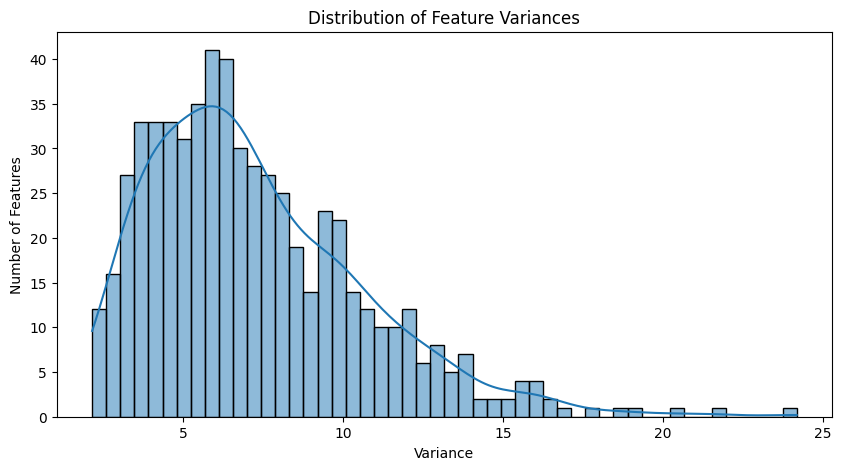

In [ ]:
# Calculate the variance of each feature in X
variances = X.var()

# Plot the distribution of variances to see it visually
plt.figure(figsize=(10, 5))
sns.histplot(variances, bins=50, kde=True)
plt.title('Distribution of Feature Variances')
plt.xlabel('Variance')
plt.ylabel('Number of Features')
plt.show()


As seen in the plot above, there are alot of feature which are near zero variance. This needs to be taken care of in the model

## Random Forest

"Random Forests exhibited the highest predictive performance, followed by Ridge Logistic Regression."

**1. Variance Threshold**

This first step acts like a "noise filter". It looks at every microbial species and removes the ones that barely change from person to person. If a microbe has a very low variance, it doesn't provide enough information to help distinguish between a Western or Non-Western lifestyle.

**2. LASSO (Feature Selection)** 

LASSO is like a "minimalist filter". In microbiome research, you often have thousands of species but only a few hundred samples. LASSO applies a mathematical penalty to the model's complexity, forcing the least helpful or redundant features to zero.

**3. Random Forest**

While LASSO is linear, the Random Forest is a non-linear "decision-maker". It builds hundreds of individual decision trees and averages their results. This is highly effective for microbiome data because it can handle complex, non-linear relationships where species interact with each other in many different ways.

**4. Nested Cross-Validation**

Normally, models can "cheat" by seeing patterns in the data they are supposed to be tested on. Nested cross-validation creates two loops:

- The Inner Loop: Tries different settings to find the best version of the model.

- The Outer Loop: Tests that "best" model on data it has never touched to get an unbiased accuracy score.

**5. StratifiedGroupKFold**

StratifiedGroupKFold acts as a defense against technical "batch effects" by ensuring that entire countries are held out of the training process to prove the model can generalize. If you have 10 countries and use 5 folds, the model trains on a bucket of 8 countries (80% of the groups) and tests itself on the remaining 2 countries (20%). The "grouping" ensures that samples from the same lab or country never leak into both training and testing sets, while the "stratified" part ensures that every bucket contains a balanced mix of Western and Non-Western samples. This forces the model to ignore technical quirks of a single lab and instead find a biological signature that works across the entire globe.

In [42]:
# Define the Pipeline
pipeline = Pipeline([
    ('var_filter', VarianceThreshold()), 
    ('lasso_selector', SelectFromModel(LogisticRegression(l1_ratio=1, solver='liblinear', class_weight='balanced', random_state=42))),
    ('rf', RandomForestClassifier(random_state=42, class_weight='balanced', n_jobs=1))
])

# Define Hyperparameter Space
param_grid = {
    'var_filter__threshold': [0, 0.0001, 0.001], 
    'lasso_selector__estimator__C': [0.1, 1.0, 10.0], 
    'rf__n_estimators': [100, 200, 300],        
    'rf__max_depth': [10, 20, None],
    'rf__max_features': ['sqrt', 'log2']          
}

# Setup Nested CV Structure
# Using GroupKFold to prevent the model from memorizing specific countries
inner_cv = StratifiedGroupKFold(n_splits=3)

rf_search = RandomizedSearchCV(
    estimator=pipeline, 
    param_distributions=param_grid, 
    n_iter=10,           
    cv=inner_cv, 
    scoring='roc_auc', 
    n_jobs=-1,          
    random_state=42
)

outer_cv = StratifiedGroupKFold(n_splits=5)

# Execute Nested CV
metrics = ['roc_auc', 'f1', 'balanced_accuracy']

# THE FIX: Added to pass groups to the inner loop!
results = cross_validate(
    rf_search, 
    X, 
    y, 
    groups=groups, 
    cv=outer_cv, 
    scoring=metrics, 
    n_jobs=-1,
    params={'groups': groups} 
)

# --- 8. Display Performance Summary ---
print("Final model performance")
print(f"Mean ROC-AUC:  {results['test_roc_auc'].mean():.4f} ± {results['test_roc_auc'].std()*2:.4f}")
print(f"Mean F1-Score: {results['test_f1'].mean():.4f} ± {results['test_f1'].std()*2:.4f}")
print(f"Mean Balanced Accuracy: {results['test_balanced_accuracy'].mean():.4f} ± {results['test_balanced_accuracy'].std()*2:.4f}")


Final model performance
Mean ROC-AUC:  0.9467 ± 0.0986
Mean F1-Score: 0.8179 ± 0.2875
Mean Balanced Accuracy: 0.8492 ± 0.2473


While an 83% average balanced accuracy seems good, the massive variations (± 0.22 to ± 0.27) tell to be cautious. These wide swings mean the model's performance fluctuates wildly depending on which specific population it is tested against.

/var/folders/d3/491fzvvs5lg2864030mq9_lw0000gn/T/ipykernel_66008/3091112171.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feat_imp.values, y=feat_imp.index, palette='viridis')


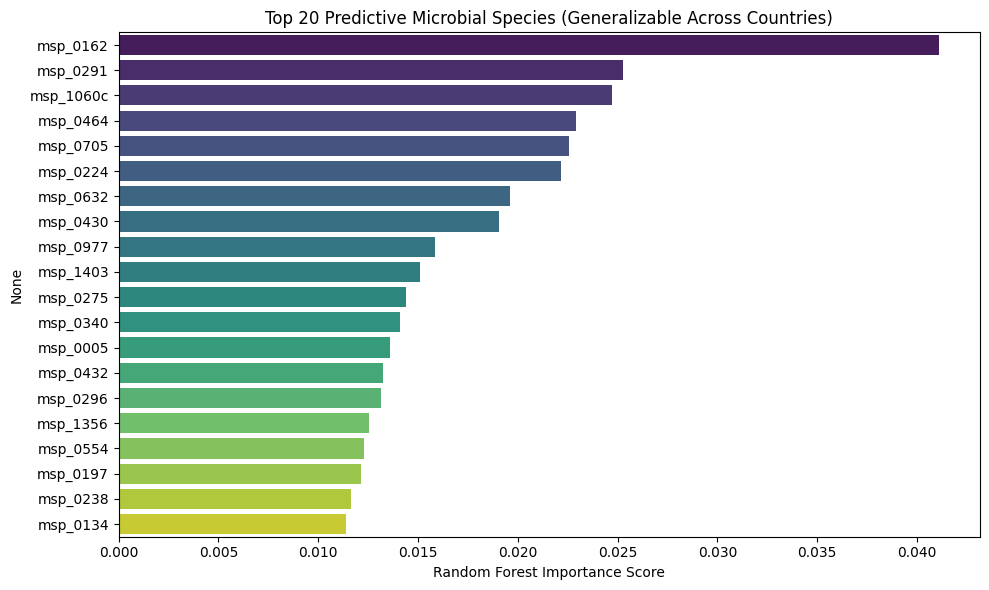

In [44]:
# # --- 9. Final Fit & Feature Importance ---
rf_search.fit(X, y, groups=groups)
best_model = rf_search.best_estimator_

# # Extracting features that survived both Variance threshold AND LASSO
var_support = best_model.named_steps['var_filter'].get_support()
lasso_support = best_model.named_steps['lasso_selector'].get_support()

# # Map back to the original column names
features_after_var = X.columns[var_support]
final_features = features_after_var[lasso_support]

# Get Random Forest Importances
importances = best_model.named_steps['rf'].feature_importances_
feat_imp = pd.Series(importances, index=final_features).sort_values(ascending=False).head(20)

# Plotting
plt.figure(figsize=(10, 6))
sns.barplot(x=feat_imp.values, y=feat_imp.index, palette='viridis')
plt.title('Top 20 Predictive Microbial Species (Generalizable Across Countries)')
plt.xlabel('Random Forest Importance Score')
plt.tight_layout()
plt.show()

The  Extracting the XAI Math: 

It loops through your most important microbes and uses the partial_dependence function to calculate the exact background coordinates that normally draw the PDP lines.

Calculating the Trend (trend_score):

It looks at the model's predicted probability of a sample being "Western" when the microbe is at its absolute lowest abundance, and subtracts that from the probability when the microbe is at its absolute highest abundance.

Objective Categorization: 

If the probability goes up overall (score > 0.001), the microbe is mathematically categorized as a "Western" marker.

If the probability goes down (score < -0.001), it is a "Non-Western" marker.

In [ ]:
direction_list = []

# Get all the top features you saved in 'feat_imp'
top_features = feat_imp.index.tolist()

for feature in top_features:
    # Extract the raw mathematical data behind the PDP plot
    pd_results = partial_dependence(best_model, X, features=[feature], grid_resolution=50)
    
    # y_values are the predicted probabilities of being "Western" (Class 1)
    y_values = pd_results['average'][0]
    
    # Calculate the overall trend (Probability at max abundance MINUS Probability at min abundance)
    trend_score = y_values[-1] - y_values[0]
    
    # Categorize it definitively 
    if trend_score > 0.001:
        category = "Western"
    elif trend_score < -0.001:
        category = "Non-Western"
    else:
        category = "Neutral / Complex"
        
    direction_list.append({
        'Microbe': feature,
        'RF_Importance': feat_imp[feature],
        'PDP_Trend_Score': trend_score,
        'Enriched_In': category
    })

# Convert to a clean DataFrame and display
final_biomarker_df = pd.DataFrame(direction_list).set_index('Microbe')

print("="*65)
print("FINAL BIOMARKER TABLE (No Guessing Required)")
print("="*65)
# Formatting the output to be readable
print(final_biomarker_df.to_string(formatters={
    'RF_Importance': '{:.4f}'.format,
    'PDP_Trend_Score': '{:.4f}'.format
}))

Calculating exact mathematical directionality for top microbes...

FINAL BIOMARKER TABLE (No Guessing Required)
          RF_Importance PDP_Trend_Score  Enriched_In
Microbe                                             
msp_0162         0.0411         -0.0840  Non-Western
msp_0291         0.0252          0.0449      Western
msp_1060c        0.0247          0.0438      Western
msp_0464         0.0229         -0.0491  Non-Western
msp_0705         0.0226         -0.0581  Non-Western
msp_0224         0.0222         -0.0462  Non-Western
msp_0632         0.0196          0.0573      Western
msp_0430         0.0191          0.0630      Western
msp_0977         0.0158          0.0230      Western
msp_1403         0.0151          0.0434      Western
msp_0275         0.0144         -0.0443  Non-Western
msp_0340         0.0141          0.0222      Western
msp_0005         0.0136         -0.0291  Non-Western
msp_0432         0.0132          0.0423      Western
msp_0296         0.0131          0.0273 